<a href="https://colab.research.google.com/github/avikumart/LLM-GenAI-Transformers-Notebooks/blob/main/LLMs_from_Scratch/Coding_attention_mech_ch03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from importlib.metadata import version

print("torch version:", version("torch"))

torch version: 2.10.0+cpu


In [2]:
# self attention in transformers
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [3]:
print(inputs)

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])


In [4]:
# calculate the attention scores
query = inputs[1]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
  attn_scores_2[i] = torch.dot(query, x_i)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [5]:
res = 0

for idx, element in enumerate(inputs[0]):
  res += inputs[0][idx] * query[idx]

print(res)
print(torch.dot(inputs[0], query))

tensor(0.9544)
tensor(0.9544)


In [6]:
# normalization of attention scores
attn_scores_2 = attn_scores_2 / torch.sum(attn_scores_2)
print(attn_scores_2)

tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])


In [7]:
## naive softmax function implementation for the scaling
def softmax_naive(x):
  return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)
print("attention weights", attn_weights_2_naive)

attention weights tensor([0.1630, 0.1770, 0.1765, 0.1603, 0.1570, 0.1663])


In [9]:
# softmax attention
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("attention weights", attn_weights_2)
print("sum", attn_weights_2.sum())

attention weights tensor([0.1630, 0.1770, 0.1765, 0.1603, 0.1570, 0.1663])
sum tensor(1.)


In [10]:
# 2nd query token for the query
query = inputs[1]

context_vec_2 = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
  context_vec_2 += attn_weights_2[i] * x_i

print(context_vec_2)

tensor([0.4325, 0.5937, 0.5349])


In [11]:
attn_scores = torch.empty(6,6)

for i, x_i in enumerate(inputs):
  for j, x_j in enumerate(inputs):
    attn_scores[i,j] = torch.dot(x_i,x_j)


print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [12]:
# now attn weights for the entire matrix
attn_weights = torch.softmax(attn_scores, dim=1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [13]:
# row wise sum
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)

print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [14]:
# all context vecs
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


In [15]:
print("Previous 2nd context vector:", context_vec_2)

Previous 2nd context vector: tensor([0.4325, 0.5937, 0.5349])


In [16]:
# computing attention weights step by step for training purpose
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2

In [17]:
torch.manual_seed(1)

W_query = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)

In [18]:
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value

print(query_2)
print(key_2)
print(value_2)

tensor([0.1191, 0.5777])
tensor([-2.3205, -0.3184])
tensor([-0.0180, -0.6356])


In [19]:
keys = inputs @ W_key
values = inputs @ W_value

print(keys)
print(values)

tensor([[-1.6031,  0.0278],
        [-2.3205, -0.3184],
        [-2.3125, -0.2983],
        [-1.2255, -0.2618],
        [-1.5187,  0.1473],
        [-1.3890, -0.4634]])
tensor([[-0.3956, -0.8296],
        [-0.0180, -0.6356],
        [-0.0220, -0.6500],
        [ 0.0630, -0.2259],
        [-0.0871, -0.7278],
        [ 0.0965, -0.1153]])


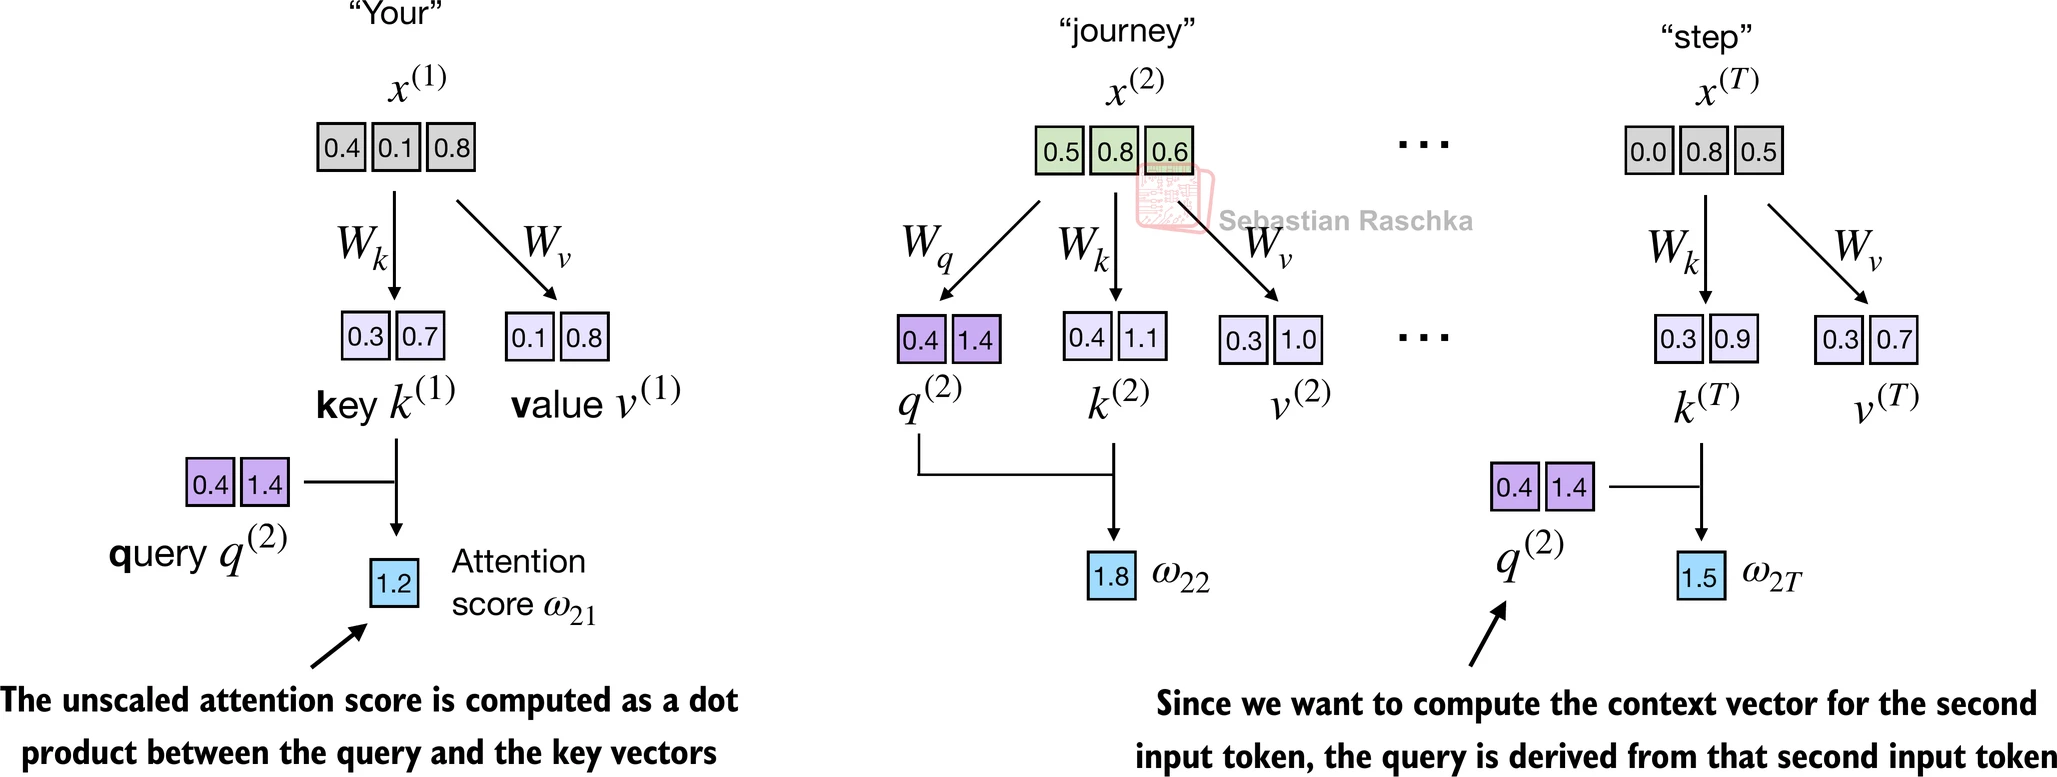

In [20]:
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(-0.4604)


In [24]:
attn_scores_2 = query_2 @ keys.T # All attention scores for given query
print(attn_scores_2)

tensor([-0.1749, -0.4604, -0.4479, -0.2973, -0.0958, -0.4332])


In [25]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1835, 0.1500, 0.1513, 0.1683, 0.1941, 0.1529])


In [26]:
# in final step 4 context vectors are calculated
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([-0.0702, -0.5428])
